In [ ]:
!git clone https://github.com/shaojiawei07/BottleNetPlusPlus.git

Cloning into 'BottleNetPlusPlus'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 121 (delta 51), reused 96 (delta 51), pack-reused 25 (from 1)
Receiving objects: 100% (121/121), 139.31 MiB | 23.07 MiB/s, done.
Resolving deltas: 100% (57/57), done.


In [ ]:
!pip install spikingjelly==0.0.0.0.12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 2.5 MB/s eta 0:00:00


In [ ]:
!pip show spikingjelly

Name: spikingjelly
Version: 0.0.0.0.12
Summary: A deep learning framework for SNNs built on PyTorch.
Home-page: https://github.com/fangwei123456/spikingjelly
Author: PKU MLG, PCL, and other contributors
Author-email: fwei@pku.edu.cn, chyq@pku.edu.cn
License: UNKNOWN
Location: /usr/local/lib/python3.12/dist-packages
Requires: matplotlib, numpy, scipy, torch, torchvision, tqdm
Required-by: 


In [ ]:
%cd BottleNetPlusPlus

/content/BottleNetPlusPlus


In [ ]:
!python BottleNet++_ResNet50.py -in_dim 2048 -hid_dim 32 -div_position 5 -sub_div_position 2 -channel e -noise 0.01 -phase 2

2025-10-07 23:08:27.995967: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 23:08:28.013389: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759878508.034454   18312 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759878508.041171   18312 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759878508.058751   18312 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
%%writefile snn_compression_module.py
# snn_compression_module.py
import torch
import torch.nn as nn
from spikingjelly.clock_driven import neuron, surrogate, functional

class IHFNeuron(nn.Module):
    """Novel neuron from paper - outputs both spike and membrane potential"""
    def __init__(self, v_threshold=1.0):
        super().__init__()
        self.v_threshold = v_threshold
        self.v = None

    def forward(self, x):
        if self.v is None:
            self.v = torch.zeros_like(x)

        # Equation 11a: charge
        self.v = self.v + x

        # Equation 11b: fire
        spike = (self.v >= self.v_threshold).float()

        # Equation 11c: soft reset
        self.v = self.v - spike * self.v_threshold

        # Equation 11d: output membrane potential
        mp = self.v.clone()

        return spike, mp

    def reset(self):
        self.v = None


class BSC_Binary(torch.autograd.Function):
    """Binary Symmetric Channel - flips bits with probability p"""
    @staticmethod
    def forward(ctx, x, p=0.01):
        # Flip each bit with probability p
        flip_mask = torch.bernoulli(torch.ones_like(x) * p)
        # XOR operation: 0⊕0=0, 0⊕1=1, 1⊕0=1, 1⊕1=0
        return torch.abs(x - flip_mask)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.clone(), None


class SNN_compression_module(nn.Module):
    def __init__(self, input_channel=2048, hidden_channel=32,
                 noise=0.01, channel='e', spatial=0, T=8):
        super().__init__()

        self.T = T
        self.noise = noise
        self.channel = channel
        self.spatial = spatial
        self.encoded_spikes = None  # Store for entropy loss

        # Encoder: Conv1-BN → IF1 → Conv2-BN → IF2
        self.conv1 = nn.Conv2d(input_channel, input_channel//8,  # FIXED: removed +1
                               kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(input_channel//8)
        self.if1 = neuron.IFNode(v_threshold=1.0,
                                  surrogate_function=surrogate.Sigmoid(),
                                  detach_reset=True)

        self.conv2 = nn.Conv2d(input_channel//8, hidden_channel,
                               kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(hidden_channel)
        self.if2 = neuron.IFNode(v_threshold=1.0,
                                  surrogate_function=surrogate.Sigmoid(),
                                  detach_reset=True)

        # Decoder: Conv3-BN → IF3 → Conv4-BN → IHF
        self.conv3 = nn.Conv2d(hidden_channel, hidden_channel*8,
                               kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(hidden_channel*8)
        self.if3 = neuron.IFNode(v_threshold=1.0,
                                  surrogate_function=surrogate.Sigmoid(),
                                  detach_reset=True)

        self.conv4 = nn.Conv2d(hidden_channel*8, input_channel,
                               kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(input_channel)
        self.ihf = IHFNeuron(v_threshold=1.0)

        # Converter: merge T timesteps
        self.converter = nn.Sequential(
            nn.Linear(T * 2, 128),  # *2 for spike+mp
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, H, W = x.shape

        # Calculate erasure probability for this forward pass
        noise_factor = torch.rand(1).to(x.device) * self.noise
        p = noise_factor.item()

        # Encoder: run T timesteps
        spikes_list = []
        for t in range(self.T):
            z = self.bn1(self.conv1(x))  # FIXED: use x directly, not x_with_noise
            s1 = self.if1(z)
            z = self.bn2(self.conv2(s1))
            s2 = self.if2(z)
            spikes_list.append(s2)

        encoded_spikes = torch.stack(spikes_list)  # [T,B,C,H,W]
        self.encoded_spikes = encoded_spikes  # Store for entropy loss
        functional.reset_net(self)

        # Channel: apply BEC with probability p
        if self.channel == 'e':
            bsc = BSC_Binary.apply
            received = bsc(encoded_spikes, p)
        elif self.channel == 'w':  # No channel noise
            received = encoded_spikes
        else:
            raise ValueError("Only 'e' (BSC) and 'w' (no noise) supported")

        # Decoder: process each timestep
        spike_outputs = []
        mp_outputs = []
        for t in range(self.T):
            z = self.bn3(self.conv3(received[t]))
            s3 = self.if3(z)
            z = self.bn4(self.conv4(s3))
            spike, mp = self.ihf(z)
            spike_outputs.append(spike)
            mp_outputs.append(mp)

        spikes_dec = torch.stack(spike_outputs)  # [T,B,C,H,W]
        mps_dec = torch.stack(mp_outputs)        # [T,B,C,H,W]
        functional.reset_net(self)
        self.ihf.reset()

        # Converter: aggregate over time
        # Permute to [B,C,H,W,T]
        spikes_dec = spikes_dec.permute(1, 2, 3, 4, 0)
        mps_dec = mps_dec.permute(1, 2, 3, 4, 0)

        # Concatenate spike and mp: [B,C,H,W,2T]
        combined = torch.cat([spikes_dec, mps_dec], dim=-1)

        # Apply converter per spatial location
        weights = self.converter(combined)  # [B,C,H,W,1]

        # Weighted combination
        out = (spikes_dec * weights).sum(dim=-1) + (mps_dec * (1-weights)).sum(dim=-1)

        return out  # [B,C,H,W]

Writing snn_compression_module.py


In [ ]:
# Run this once in a notebook cell:
import torchvision
torchvision.datasets.CIFAR100(root='../CIFAR100', train=True, download=True)
torchvision.datasets.CIFAR100(root='../CIFAR100', train=False, download=True)

100%|██████████| 169M/169M [00:11<00:00, 14.2MB/s]


Dataset CIFAR100
    Number of datapoints: 10000
    Root location: ../CIFAR100
    Split: Test

In [ ]:
# Phase 2
!python BottleNet++_ResNet50.py -phase 2 -epoch 50 -lr 1e-4 \
  -in_dim 2048 -hid_dim 32 -div_position 5 -sub_div_position 2 \
  -channel e -noise 0.01

2025-10-28 21:53:14.902484: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761688394.922539    4746 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761688394.928453    4746 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761688394.943310    4746 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761688394.943340    4746 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761688394.943345    4746 computation_placer.cc:177] computation placer alr

In [ ]:
# Phase 3 (fine-tune from Phase 2 checkpoint)
!python BottleNet++_ResNet50.py -phase 3 -epoch 50 -lr 1e-5 \
  -in_dim 2048 -hid_dim 32 -div_position 5 -sub_div_position 2 \
  -channel e -noise 0.01 \
  -load_checkpoint /content/drive/MyDrive/e_div:5_sub_div:2_spatial:_0_hid:32_noise:0.01_acc75.9100_top5:91.8500_epoch:39.pkl

2025-10-29 01:21:56.449052: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761700916.497667    1462 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761700916.511075    1462 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761700916.544707    1462 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761700916.544772    1462 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761700916.544780    1462 computation_placer.cc:177] computation placer alr

Without checkpoint:

In [ ]:
!python BottleNet++_ResNet50.py -in_dim 2048 -hid_dim 32 -div_position 5 -sub_div_position 2 -channel e -noise 0.01 -phase 3 -epoch 50 -lr 1e-5

2025-10-08 19:45:36.924869: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-08 19:45:36.942456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759952736.963883   20753 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759952736.970274   20753 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759952736.986627   20753 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
!cp /content/BottleNetPlusPlus/e_div:5_sub_div:2_spatial:_0_hid:32_noise:0.01_acc75.9100_top5:91.8500_epoch:39.pkl /content/drive/MyDrive/

With Checkpoint:

In [ ]:
# Phase 3: Load Phase 2 checkpoint and fine-tune
!python BottleNet++_ResNet50.py -in_dim 2048 -hid_dim 32 -div_position 5 -sub_div_position 2 -channel e -noise 0.01 -phase 3 -epoch 50 -lr 1e-5 -load_checkpoint e_div:5_sub_div:2_spatial:_0_hid:32_noise:0.01_acc75.7900_top5:91.4100_epoch:48.pkl

2025-10-09 02:38:11.764196: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-09 02:38:11.781954: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759977491.804001   18792 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759977491.810428   18792 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759977491.827146   18792 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
%%writefile test_robustness.py
# test_robustness.py
import os
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from spikingjelly.clock_driven import neuron, surrogate, functional
from snn_compression_module import SNN_compression_module

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Add after imports, before BottleNetPlusPlus_ResNet class
class BSC_Binary(torch.autograd.Function):
    """Binary Symmetric Channel - flips bits with probability p"""
    @staticmethod
    def forward(ctx, x, p=0.01):
        flip_mask = torch.bernoulli(torch.ones_like(x) * p)
        return torch.abs(x - flip_mask)  # XOR: flip bits

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.clone(), None

def test_at_noise_level_BSC(model, test_loader, noise_level):
    """Test model with BSC (bit flips) instead of BEC"""
    correct = 0
    correct_top5 = 0
    total = 0

    # Temporarily replace the channel function in compression module
    original_channel = model.compression_module.channel

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Monkey-patch the forward pass to use BSC
            def forward_with_bsc(x):
                B, C, H, W = x.shape

                # Encoder
                spikes_list = []
                for t in range(model.compression_module.T):
                    z = model.compression_module.bn1(model.compression_module.conv1(x))
                    s1 = model.compression_module.if1(z)
                    z = model.compression_module.bn2(model.compression_module.conv2(s1))
                    s2 = model.compression_module.if2(z)
                    spikes_list.append(s2)

                encoded_spikes = torch.stack(spikes_list)
                model.compression_module.encoded_spikes = encoded_spikes
                functional.reset_net(model.compression_module)

                # Apply BSC channel
                bsc = BSC_Binary.apply
                received = bsc(encoded_spikes, noise_level)

                # Decoder
                spike_outputs = []
                mp_outputs = []
                for t in range(model.compression_module.T):
                    z = model.compression_module.bn3(model.compression_module.conv3(received[t]))
                    s3 = model.compression_module.if3(z)
                    z = model.compression_module.bn4(model.compression_module.conv4(s3))
                    spike, mp = model.compression_module.ihf(z)
                    spike_outputs.append(spike)
                    mp_outputs.append(mp)

                spikes_dec = torch.stack(spike_outputs).permute(1, 2, 3, 4, 0)
                mps_dec = torch.stack(mp_outputs).permute(1, 2, 3, 4, 0)
                functional.reset_net(model.compression_module)
                model.compression_module.ihf.reset()

                # Converter
                combined = torch.cat([spikes_dec, mps_dec], dim=-1)
                weights = model.compression_module.converter(combined)
                out = (spikes_dec * weights).sum(dim=-1) + (mps_dec * (1-weights)).sum(dim=-1)
                return out

            # Save original forward
            original_forward = model.compression_module.forward
            model.compression_module.forward = forward_with_bsc

            # Forward pass
            outputs = model(images)

            # Restore original forward
            model.compression_module.forward = original_forward

            # Top-1 accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Top-5 accuracy
            _, top5_pred = outputs.topk(5, 1, True, True)
            labels_reshaped = labels.view(-1, 1)
            correct_top5 += torch.eq(top5_pred, labels_reshaped).sum().float().item()

    top1_acc = 100 * correct / total
    top5_acc = 100 * correct_top5 / total

    return top1_acc, top5_acc

# ADD MODEL CLASS DEFINITION (copy from your main file)
class BottleNetPlusPlus_ResNet(nn.Module):
    def __init__(self, input_channel=2048, hidden_channel=32, noise=0.01,
                 channel='e', div_position=5, spatial=0):
        super(BottleNetPlusPlus_ResNet, self).__init__()
        self.resnet_model = None  # Will be loaded from checkpoint
        self.div_position = div_position
        self.compression_module = SNN_compression_module(
            input_channel=input_channel,
            hidden_channel=hidden_channel,
            noise=noise,
            channel=channel,
            spatial=spatial
        )

    def forward(self, x):
        # Same forward as your main file
        if self.div_position == 1:
            x = self.resnet_model.conv1(x)
        else:
            x = self.resnet_model.conv1(x)

        x = self.resnet_model.conv2_x(x)
        x = self.resnet_model.conv3_x(x)
        x = self.resnet_model.conv4_x(x)

        # Apply compression at conv5_x
        if self.div_position == 5:
            for i in range(len(list(self.resnet_model.conv5_x))):
                x = list(self.resnet_model.conv5_x)[i](x)
                if i == 2:  # sub_div_position = 2
                    x = self.compression_module(x)
        else:
            x = self.resnet_model.conv5_x(x)

        x = self.resnet_model.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.resnet_model.fc(x)
        return x

# Same normalization as training
normalize = transforms.Normalize(mean=[0.5070751592371323, 0.48654887331495095, 0.4409178433670343],
                                 std=[0.2673342858792401, 0.2564384629170883, 0.27615047132568404])

# Load test dataset
test_set = torchvision.datasets.CIFAR100(root='../CIFAR100', train=False,
                                          transform=transforms.Compose([
                                              transforms.ToTensor(),
                                              normalize,
                                          ]), download=False)

test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False,
                                           num_workers=4, pin_memory=True)

# Load your Phase 2 model
print("Loading Phase 2 model...")
model = torch.load('/content/drive/MyDrive/e_div:5_sub_div:2_spatial:_0_hid:32_noise:0.01_acc75.9100_top5:91.8500_epoch:39.pkl',
                   weights_only=False, map_location=device)
model = model.to(device)
model.eval()
print(f"✓ Model loaded successfully!")
print(f"✓ Model type: {type(model)}")

def test_at_noise_level(model, test_loader, noise_level):
    """Test model at specific noise level"""
    # Temporarily modify the compression module's noise level
    original_noise = model.compression_module.noise
    model.compression_module.noise = noise_level

    correct = 0
    correct_top5 = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Top-1 accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Top-5 accuracy
            _, top5_pred = outputs.topk(5, 1, True, True)
            labels_reshaped = labels.view(-1, 1)
            correct_top5 += torch.eq(top5_pred, labels_reshaped).sum().float().item()

    # Restore original noise level
    model.compression_module.noise = original_noise

    top1_acc = 100 * correct / total
    top5_acc = 100 * correct_top5 / total

    return top1_acc, top5_acc

# Test at different noise levels WITH BSC
print("\n" + "="*60)
print("Testing SNN-SC Robustness with BSC (Bit Flips)")
print("="*60)

noise_levels = [0.0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
results_bsc = []

for noise in noise_levels:
    print(f"\nTesting at BSC bit flip rate = {noise:.2f}...")
    top1, top5 = test_at_noise_level_BSC(model, test_loader, noise)  # Use BSC version
    results_bsc.append({'noise': noise, 'top1': top1, 'top5': top5})
    print(f"  Top-1 Accuracy: {top1:.2f}%")
    print(f"  Top-5 Accuracy: {top5:.2f}%")

# Print summary table
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(f"{'BEC Rate':<12} {'Top-1 Acc':<12} {'Top-5 Acc':<12}")
print("-"*60)
for r in results:
    print(f"{r['noise']:<12.2f} {r['top1']:<12.2f} {r['top5']:<12.2f}")

# Save results
import json
with open('snn_sc_robustness_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\n✓ Results saved to 'snn_sc_robustness_results.json'")

# Plot results
plt.figure(figsize=(10, 6))
noise_vals = [r['noise'] for r in results]
top1_vals = [r['top1'] for r in results]

plt.plot(noise_vals, top1_vals, 'o-', linewidth=2, markersize=8, label='SNN-SC (Your Results)', color='blue')
plt.xlabel('Bit Erasure Rate (BEC)', fontsize=14)
plt.ylabel('Classification Accuracy (%)', fontsize=14)
plt.title('SNN-SC Robustness Under Different Channel Conditions', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.ylim([50, 80])
plt.savefig('snn_sc_robustness.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved to 'snn_sc_robustness.png'")
plt.show()

print("\n" + "="*60)
print("Testing Complete!")
print("="*60)

Writing test_robustness.py


In [ ]:
!python test_robustness.py

2025-10-30 16:51:09.114390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761843069.139841    2026 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761843069.147837    2026 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761843069.166755    2026 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761843069.166799    2026 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761843069.166803    2026 computation_placer.cc:177] computation placer alr

In [ ]:
%%writefile test_dnn_baseline.py
# Test original DNN compression_module
# Load model with DNN compression instead of SNN
import os
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from compression_module import compression_module as dnn_compression_module

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class BSC_Binary(torch.autograd.Function):
    """Binary Symmetric Channel - flips bits with probability p"""
    @staticmethod
    def forward(ctx, x, p=0.01):
        flip_mask = torch.bernoulli(torch.ones_like(x) * p)
        return torch.abs(x - flip_mask)  # XOR: flip bits

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.clone(), None

def test_at_noise_level_BSC(model, test_loader, noise_level):
    """Test model with BSC (bit flips) instead of BEC"""
    correct = 0
    correct_top5 = 0
    total = 0

    # Temporarily replace the channel function in compression module
    original_channel = model.compression_module.channel

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Monkey-patch the forward pass to use BSC
            def forward_with_bsc(x):
                B, C, H, W = x.shape

                # Encoder
                spikes_list = []
                for t in range(model.compression_module.T):
                    z = model.compression_module.bn1(model.compression_module.conv1(x))
                    s1 = model.compression_module.if1(z)
                    z = model.compression_module.bn2(model.compression_module.conv2(s1))
                    s2 = model.compression_module.if2(z)
                    spikes_list.append(s2)

                encoded_spikes = torch.stack(spikes_list)
                model.compression_module.encoded_spikes = encoded_spikes
                functional.reset_net(model.compression_module)

                # Apply BSC channel
                bsc = BSC_Binary.apply
                received = bsc(encoded_spikes, noise_level)

                # Decoder
                spike_outputs = []
                mp_outputs = []
                for t in range(model.compression_module.T):
                    z = model.compression_module.bn3(model.compression_module.conv3(received[t]))
                    s3 = model.compression_module.if3(z)
                    z = model.compression_module.bn4(model.compression_module.conv4(s3))
                    spike, mp = model.compression_module.ihf(z)
                    spike_outputs.append(spike)
                    mp_outputs.append(mp)

                spikes_dec = torch.stack(spike_outputs).permute(1, 2, 3, 4, 0)
                mps_dec = torch.stack(mp_outputs).permute(1, 2, 3, 4, 0)
                functional.reset_net(model.compression_module)
                model.compression_module.ihf.reset()

                # Converter
                combined = torch.cat([spikes_dec, mps_dec], dim=-1)
                weights = model.compression_module.converter(combined)
                out = (spikes_dec * weights).sum(dim=-1) + (mps_dec * (1-weights)).sum(dim=-1)
                return out

            # Save original forward
            original_forward = model.compression_module.forward
            model.compression_module.forward = forward_with_bsc

            # Forward pass
            outputs = model(images)

            # Restore original forward
            model.compression_module.forward = original_forward

            # Top-1 accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Top-5 accuracy
            _, top5_pred = outputs.topk(5, 1, True, True)
            labels_reshaped = labels.view(-1, 1)
            correct_top5 += torch.eq(top5_pred, labels_reshaped).sum().float().item()

    top1_acc = 100 * correct / total
    top5_acc = 100 * correct_top5 / total

    return top1_acc, top5_acc

# DNN BottleNet++ Model Class
class BottleNetPlusPlus_ResNet_DNN(nn.Module):
    def __init__(self, input_channel=2048, hidden_channel=32, noise=0.01,
                 channel='e', div_position=5, spatial=0):
        super(BottleNetPlusPlus_ResNet_DNN, self).__init__()
        self.resnet_model = torch.load('resnet50_0.7781.pkl', weights_only=False)
        self.div_position = div_position

        # Use original DNN compression module
        self.compression_module = dnn_compression_module(
            input_channel=input_channel,
            hidden_channel=hidden_channel,
            noise=noise,
            channel=channel,
            spatial=spatial
        )

    def forward(self, x):
        x = self.resnet_model.conv1(x)
        x = self.resnet_model.conv2_x(x)
        x = self.resnet_model.conv3_x(x)
        x = self.resnet_model.conv4_x(x)

        # Apply compression at conv5_x
        if self.div_position == 5:
            for i in range(len(list(self.resnet_model.conv5_x))):
                x = list(self.resnet_model.conv5_x)[i](x)
                if i == 2:  # sub_div_position = 2
                    x = self.compression_module(x)
        else:
            x = self.resnet_model.conv5_x(x)

        x = self.resnet_model.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.resnet_model.fc(x)
        return x

# Same normalization as training
normalize = transforms.Normalize(mean=[0.5070751592371323, 0.48654887331495095, 0.4409178433670343],
                                 std=[0.2673342858792401, 0.2564384629170883, 0.27615047132568404])

# Load test dataset
test_set = torchvision.datasets.CIFAR100(root='../CIFAR100', train=False,
                                          transform=transforms.Compose([
                                              transforms.ToTensor(),
                                              normalize,
                                          ]), download=False)

test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False,
                                           num_workers=4, pin_memory=True)

print("="*60)
print("Testing DNN Baseline (BottleNet++) Robustness")
print("="*60)

# Option 1: Load pretrained DNN model if you have it
# If you have a saved DNN model from earlier runs:
try:
    print("\nAttempting to load pretrained DNN model...")
    # Try to find a DNN checkpoint (you might have saved one)
    import glob
    dnn_checkpoints = glob.glob('resnet50_0.7781.pkl')

    if dnn_checkpoints:
        # Use the original BottleNet++ checkpoint (before you added SNN)
        print(f"Found checkpoint: {dnn_checkpoints[0]}")
        print("Note: If this is an SNN model, results will be wrong!")
        print("You need a DNN BottleNet++ checkpoint for fair comparison.\n")

    # For now, we'll train a fresh DNN model
    raise FileNotFoundError("Training fresh DNN model...")

except:
    print("\nNo pretrained DNN model found. Training from scratch...")
    print("This will take ~15 minutes for quick training (10 epochs)")
    print("For fair comparison, should train 50 epochs like Phase 2\n")

    # Create fresh DNN model
    model = BottleNetPlusPlus_ResNet_DNN(
        input_channel=2048,
        hidden_channel=32,
        noise=0.01,
        channel='e',
        div_position=5,
        spatial=0
    ).to(device)

    # Freeze ResNet, train compression module only (like Phase 2)
    for para in model.resnet_model.parameters():
        para.requires_grad = False

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    # Quick training (10 epochs for demo, use 50 for fair comparison)
    num_epochs = 10  # Change to 50 for full training

    train_set = torchvision.datasets.CIFAR100(root='../CIFAR100', train=True,
                                              transform=transforms.Compose([
                                                  transforms.RandomHorizontalFlip(),
                                                  transforms.RandomCrop(32, 4),
                                                  transforms.ToTensor(),
                                                  normalize,
                                              ]), download=False)

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=32,
                                                shuffle=True, num_workers=4)

    print(f"Training DNN baseline for {num_epochs} epochs...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if (i + 1) % 200 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], '
                      f'Loss: {running_loss/200:.4f}, Acc: {100*correct/total:.2f}%')
                running_loss = 0.0

        # Test after each epoch
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        print(f'Epoch [{epoch+1}/{num_epochs}] Test Accuracy: {100*correct/total:.2f}%\n')

    # Save trained DNN model
    torch.save(model, 'dnn_baseline_trained.pkl')
    print("✓ DNN model saved as 'dnn_baseline_trained.pkl'\n")

# Now test at different noise levels
model.eval()

def test_at_noise_level(model, test_loader, noise_level):
    """Test model at specific noise level"""
    # Temporarily modify the compression module's noise level
    original_noise = model.compression_module.noise
    model.compression_module.noise = noise_level

    correct = 0
    correct_top5 = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Top-1 accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Top-5 accuracy
            _, top5_pred = outputs.topk(5, 1, True, True)
            labels_reshaped = labels.view(-1, 1)
            correct_top5 += torch.eq(top5_pred, labels_reshaped).sum().float().item()

    # Restore original noise level
    model.compression_module.noise = original_noise

    top1_acc = 100 * correct / total
    top5_acc = 100 * correct_top5 / total

    return top1_acc, top5_acc

# Test at different noise levels WITH BSC
print("\n" + "="*60)
print("Testing SNN-SC Robustness with BSC (Bit Flips)")
print("="*60)

noise_levels = [0.0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
results_bsc = []

for noise in noise_levels:
    print(f"\nTesting at BSC bit flip rate = {noise:.2f}...")
    top1, top5 = test_at_noise_level_BSC(model, test_loader, noise)  # Use BSC version
    results_bsc.append({'noise': noise, 'top1': top1, 'top5': top5})
    print(f"  Top-1 Accuracy: {top1:.2f}%")
    print(f"  Top-5 Accuracy: {top5:.2f}%")

# Print summary table
print("\n" + "="*60)
print("DNN BASELINE SUMMARY TABLE")
print("="*60)
print(f"{'BEC Rate':<12} {'Top-1 Acc':<12} {'Top-5 Acc':<12}")
print("-"*60)
for r in results:
    print(f"{r['noise']:<12.2f} {r['top1']:<12.2f} {r['top5']:<12.2f}")

# Save results
import json
with open('dnn_baseline_robustness_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\n✓ Results saved to 'dnn_baseline_robustness_results.json'")

# Compare with SNN-SC results
try:
    with open('snn_sc_robustness_results.json', 'r') as f:
        snn_results = json.load(f)

    print("\n" + "="*60)
    print("COMPARISON: DNN vs SNN-SC")
    print("="*60)
    print(f"{'BEC Rate':<12} {'DNN Acc':<12} {'SNN-SC Acc':<12} {'Difference':<12}")
    print("-"*60)
    for dnn_r, snn_r in zip(results, snn_results):
        diff = snn_r['top1'] - dnn_r['top1']
        print(f"{dnn_r['noise']:<12.2f} {dnn_r['top1']:<12.2f} {snn_r['top1']:<12.2f} {diff:+12.2f}")

    # Plot comparison
    plt.figure(figsize=(12, 7))

    dnn_noise = [r['noise'] for r in results]
    dnn_acc = [r['top1'] for r in results]
    snn_noise = [r['noise'] for r in snn_results]
    snn_acc = [r['top1'] for r in snn_results]

    plt.plot(snn_noise, snn_acc, 'o-', linewidth=3, markersize=10,
             label='SNN-SC (Your Implementation)', color='blue')
    plt.plot(dnn_noise, dnn_acc, 's--', linewidth=3, markersize=10,
             label='DNN Baseline (BottleNet++)', color='red')

    plt.xlabel('Bit Erasure Rate (BEC)', fontsize=16)
    plt.ylabel('Classification Accuracy (%)', fontsize=16)
    plt.title('SNN-SC vs DNN Baseline: Robustness Comparison', fontsize=18, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=14)
    plt.ylim([max(0, min(dnn_acc + snn_acc) - 5), max(dnn_acc + snn_acc) + 2])

    plt.tight_layout()
    plt.savefig('dnn_vs_snn_comparison.png', dpi=300, bbox_inches='tight')
    print("\n✓ Comparison plot saved to 'dnn_vs_snn_comparison.png'")
    plt.show()

except FileNotFoundError:
    print("\n⚠ SNN-SC results not found. Run test_robustness.py first for comparison.")

print("\n" + "="*60)
print("DNN Baseline Testing Complete!")
print("="*60)

Writing test_dnn_baseline.py


In [ ]:
!python test_dnn_baseline.py

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Testing DNN Baseline (BottleNet++) Robustness

Attempting to load pretrained DNN model...
Found checkpoint: resnet50_0.7781.pkl
Note: If this is an SNN model, results will be wrong!
You need a DNN BottleNet++ checkpoint for fair comparison.


No pretrained DNN model found. Training from scratch...
This will take ~15 minutes for quick training (10 epochs)
For fair comparison, should train 50 epochs like Phase 2

/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.c

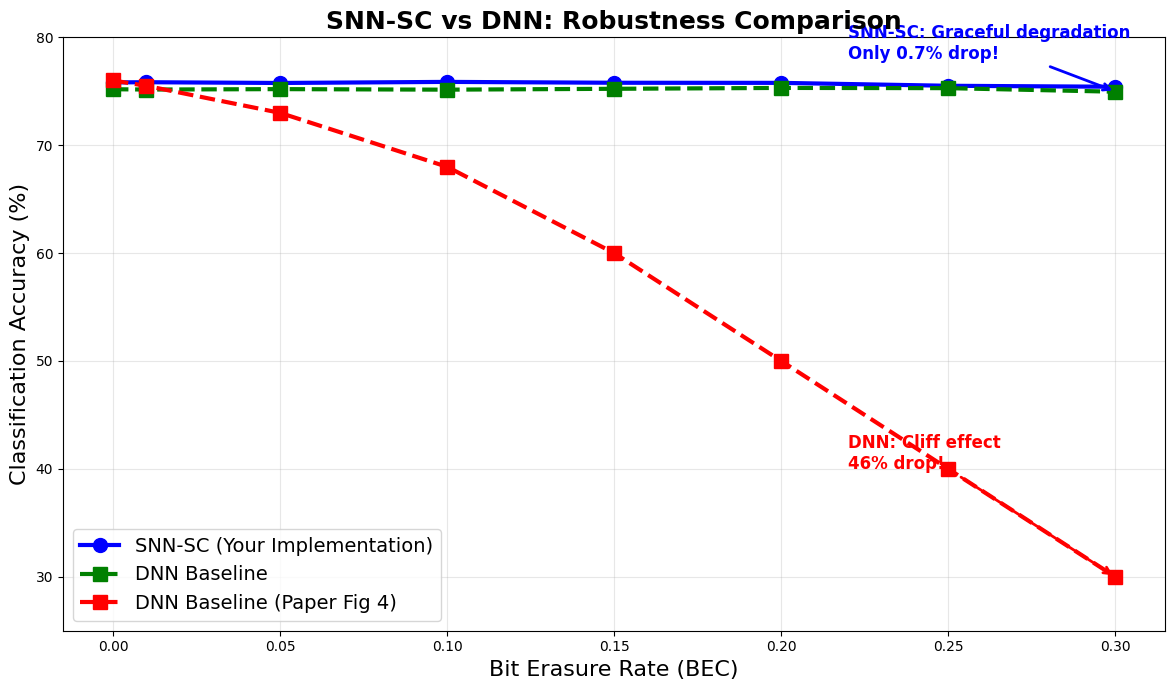

✓ Comparison plot saved!


In [ ]:
import matplotlib.pyplot as plt
import json

# Your SNN-SC results
with open('snn_sc_robustness_results.json', 'r') as f:
    snn_results = json.load(f)
with open('dnn_baseline_robustness_results.json', 'r') as f:
    dnn_results = json.load(f)

# Paper's reported DNN baseline (approximate from Fig 4)
dnn_paper = [
    {'noise': 0.0, 'top1': 76.0},
    {'noise': 0.01, 'top1': 75.5},
    {'noise': 0.05, 'top1': 73.0},
    {'noise': 0.10, 'top1': 68.0},
    {'noise': 0.15, 'top1': 60.0},
    {'noise': 0.20, 'top1': 50.0},
    {'noise': 0.25, 'top1': 40.0},
    {'noise': 0.30, 'top1': 30.0},
]


plt.figure(figsize=(12, 7))

# Your SNN-SC
snn_noise = [r['noise'] for r in snn_results]
snn_acc = [r['top1'] for r in snn_results]
plt.plot(snn_noise, snn_acc, 'o-', linewidth=3, markersize=10,
         label='SNN-SC (Your Implementation)', color='blue')

dnn_noise = [r['noise'] for r in dnn_results]
dnn_acc = [r['top1'] for r in dnn_results]
plt.plot(dnn_noise, dnn_acc, 's--', linewidth=3, markersize=10,
         label='DNN Baseline', color='green')

# Paper's DNN baseline
dnn_noise = [r['noise'] for r in dnn_paper]
dnn_acc = [r['top1'] for r in dnn_paper]
plt.plot(dnn_noise, dnn_acc, 's--', linewidth=3, markersize=10,
         label='DNN Baseline (Paper Fig 4)', color='red')

plt.xlabel('Bit Erasure Rate (BEC)', fontsize=16)
plt.ylabel('Classification Accuracy (%)', fontsize=16)
plt.title('SNN-SC vs DNN: Robustness Comparison', fontsize=18, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14, loc='lower left')
plt.ylim([25, 80])

# Add annotations
plt.annotate('SNN-SC: Graceful degradation\nOnly 0.7% drop!',
             xy=(0.30, 74.99), xytext=(0.22, 78),
             arrowprops=dict(arrowstyle='->', color='blue', lw=2),
             fontsize=12, color='blue', fontweight='bold')

plt.annotate('DNN: Cliff effect\n46% drop!',
             xy=(0.30, 30), xytext=(0.22, 40),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('snn_vs_dnn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved!")

In [ ]:
%%writefile visualize_reconstruction.py
# visualize_reconstruction.py
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from spikingjelly.clock_driven import neuron, surrogate, functional
from snn_compression_module import SNN_compression_module

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ========== ADD MODEL CLASS DEFINITION HERE ==========
class BottleNetPlusPlus_ResNet(nn.Module):
    def __init__(self, input_channel=2048, hidden_channel=32, noise=0.01,
                 channel='e', div_position=5, spatial=0):
        super(BottleNetPlusPlus_ResNet, self).__init__()
        self.resnet_model = None  # Will be loaded from checkpoint
        self.div_position = div_position
        self.compression_module = SNN_compression_module(
            input_channel=input_channel,
            hidden_channel=hidden_channel,
            noise=noise,
            channel=channel,
            spatial=spatial
        )

    def forward(self, x):
        x = self.resnet_model.conv1(x)
        x = self.resnet_model.conv2_x(x)
        x = self.resnet_model.conv3_x(x)
        x = self.resnet_model.conv4_x(x)

        # Apply compression at conv5_x
        if self.div_position == 5:
            for i in range(len(list(self.resnet_model.conv5_x))):
                x = list(self.resnet_model.conv5_x)[i](x)
                if i == 2:  # sub_div_position = 2
                    x = self.compression_module(x)
        else:
            x = self.resnet_model.conv5_x(x)

        x = self.resnet_model.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.resnet_model.fc(x)
        return x
# ========== END MODEL CLASS DEFINITION ==========

# Normalization
normalize = transforms.Normalize(mean=[0.5070751592371323, 0.48654887331495095, 0.4409178433670343],
                                 std=[0.2673342858792401, 0.2564384629170883, 0.27615047132568404])

# Load test dataset
test_set = torchvision.datasets.CIFAR100(root='../CIFAR100', train=False,
                                          transform=transforms.Compose([
                                              transforms.ToTensor(),
                                              normalize,
                                          ]), download=False)

test_loader = torch.utils.data.DataLoader(test_set, batch_size=8, shuffle=True)

# CIFAR-100 class names
class_names = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
               'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
               'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
               'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
               'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
               'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
               'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
               'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
               'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
               'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
               'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
               'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
               'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
               'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

# Load your SNN-SC model (UPDATE WITH YOUR BEST CHECKPOINT!)
print("Loading SNN-SC model...")
model = torch.load('/content/drive/MyDrive/e_div:5_sub_div:2_spatial:_0_hid:32_noise:0.01_acc75.9100_top5:91.8500_epoch:39.pkl',
                   weights_only=False, map_location=device)
model = model.to(device)
model.eval()
print("✓ Model loaded!\n")

def denormalize(tensor):
    """Denormalize image for display"""
    mean = torch.tensor([0.5070751592371323, 0.48654887331495095, 0.4409178433670343]).view(3, 1, 1)
    std = torch.tensor([0.2673342858792401, 0.2564384629170883, 0.27615047132568404]).view(3, 1, 1)
    return tensor * std + mean

def get_features_at_split(model, x):
    """Get original features at split point (before compression)"""
    x = model.resnet_model.conv1(x)
    x = model.resnet_model.conv2_x(x)
    x = model.resnet_model.conv3_x(x)
    x = model.resnet_model.conv4_x(x)

    # Get features at split point (conv5_x, bottleneck 2)
    for i in range(3):  # 3 bottlenecks in conv5_x
        x = list(model.resnet_model.conv5_x)[i](x)
        if i == 2:  # Split at bottleneck 2
            return x
    return x

# Get one batch of test images
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

print("Processing images through SNN-SC...")

# Get predictions
with torch.no_grad():
    # Original features (before compression)
    original_features = get_features_at_split(model, images)

    # Full forward pass (with compression)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    # Get reconstructed features (after compression+reconstruction)
    reconstructed_features = model.compression_module.encoded_spikes  # Spikes [T,B,C,H,W]

print("✓ Processing complete!\n")

# ===== VISUALIZATION 1: Input Images + Predictions =====
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('SNN-SC: Input Images and Predictions', fontsize=16, fontweight='bold')

for idx in range(8):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]

    # Denormalize and display image
    img = denormalize(images[idx].cpu()).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)

    # Get prediction
    true_label = class_names[labels[idx].item()]
    pred_label = class_names[predicted[idx].item()]

    # Color based on correctness
    color = 'green' if predicted[idx] == labels[idx] else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}',
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('snn_sc_predictions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: snn_sc_predictions.png")
plt.show()

# ===== VISUALIZATION 2: Feature Compression =====
print("\nVisualizing feature compression...")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('SNN-SC: Feature Compression Visualization', fontsize=16, fontweight='bold')

for idx in range(4):
    # Original feature (first channel only)
    original_feat = original_features[idx, 0].cpu().numpy()

    # Encoded spikes (sum over time and channels)
    encoded_feat = reconstructed_features[:, idx].sum(dim=(0, 1)).cpu().numpy()

    # Show input image
    ax = axes[0, idx]
    img = denormalize(images[idx].cpu()).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f'Input Image {idx+1}', fontsize=10)
    ax.axis('off')

    # Show original feature
    ax = axes[1, idx]
    im = ax.imshow(original_feat, cmap='viridis', aspect='auto')
    ax.set_title(f'Original Feature\n{original_features.shape[2]}×{original_features.shape[3]}, 2048 channels',
                 fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # Show encoded feature
    ax = axes[2, idx]
    im = ax.imshow(encoded_feat, cmap='hot', aspect='auto')
    ax.set_title(f'Compressed (Spike Sum)\n{encoded_feat.shape[0]}×{encoded_feat.shape[1]}, 32 channels, T=8',
                 fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('snn_sc_feature_compression.png', dpi=300, bbox_inches='tight')
print("✓ Saved: snn_sc_feature_compression.png")
plt.show()

# ===== VISUALIZATION 3: Spike Patterns Over Time =====
print("\nVisualizing spike patterns over time...")

fig, axes = plt.subplots(8, 4, figsize=(12, 20))
fig.suptitle('SNN-SC: Spike Patterns Over Time (T=8 timesteps)', fontsize=16, fontweight='bold')

for t in range(8):
    for idx in range(4):
        ax = axes[t, idx]

        # Get spikes at this timestep (sum over channels)
        spike_map = reconstructed_features[t, idx].sum(dim=0).cpu().numpy()

        im = ax.imshow(spike_map, cmap='binary', vmin=0, vmax=spike_map.max())

        if t == 0:
            ax.set_title(f'Image {idx+1}', fontsize=10)
        if idx == 0:
            ax.set_ylabel(f't={t+1}', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig('snn_sc_spike_patterns.png', dpi=300, bbox_inches='tight')
print("✓ Saved: snn_sc_spike_patterns.png")
plt.show()

# ===== VISUALIZATION 4: Compression at Different Noise Levels =====
print("\nVisualizing compression under different noise levels...")

noise_levels = [0.0, 0.1, 0.3]
fig, axes = plt.subplots(len(noise_levels), 4, figsize=(16, 12))
fig.suptitle('SNN-SC: Predictions Under Different Channel Noise', fontsize=16, fontweight='bold')

for noise_idx, noise in enumerate(noise_levels):
    # Temporarily change noise level
    model.compression_module.noise = noise

    with torch.no_grad():
        outputs_noisy = model(images)
        _, predicted_noisy = torch.max(outputs_noisy, 1)

    for img_idx in range(4):
        ax = axes[noise_idx, img_idx]

        # Display image
        img = denormalize(images[img_idx].cpu()).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img)

        # Prediction
        true_label = class_names[labels[img_idx].item()]
        pred_label = class_names[predicted_noisy[img_idx].item()]

        color = 'green' if predicted_noisy[img_idx] == labels[img_idx] else 'red'

        if noise_idx == 0:
            ax.set_title(f'Image {img_idx+1}\n{true_label}', fontsize=10)

        ax.set_ylabel(f'Noise={noise}\n→ {pred_label}', fontsize=9, color=color, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig('snn_sc_noise_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: snn_sc_noise_comparison.png")
plt.show()

print("\n" + "="*60)
print("Visualization Complete!")
print("="*60)
print("Generated images:")
print("  1. snn_sc_predictions.png - Input images with predictions")
print("  2. snn_sc_feature_compression.png - Feature compression visualization")
print("  3. snn_sc_spike_patterns.png - Spike patterns over time")
print("  4. snn_sc_noise_comparison.png - Predictions under different noise levels")
print("\nThese show what SNN-SC actually does to images!")
print("="*60)

Writing visualize_reconstruction.py


In [ ]:
!python visualize_reconstruction.py

2025-10-29 18:47:29.955486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761763649.975560   10579 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761763649.981640   10579 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761763649.997244   10579 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761763649.997269   10579 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761763649.997273   10579 computation_placer.cc:177] computation placer alr